# A. Forecasting Future Car Sales Using Machine Learning to Support Inventory and Demand Planning.


In [945]:
# STEP 1: imports & options

import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


In [1068]:
# step 2:Load the dataset

df=pd.read_csv("Automobile_sales_data_project.csv")
print(df)

      ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER  SALES  \
0           10391               33        253                8   8345   
1           10322               50        251                6  12537   
2           10112               29        249                1   7209   
3           10153               20        245               11   4904   
4           10348               29        245                6   7111   
...           ...              ...        ...              ...    ...   
2742        10193               26         29               10    759   
2743        10227               42         29                6   1227   
2744        10280               20         29               12    578   
2745        10195               32         28                7    905   
2746        10420               45         27                1   1210   

     ORDERDATE  DAYS_SINCE_LASTORDER      STATUS   PRODUCTLINE  MSRP  \
0     09-03-20                  1591     Shipped  V

In [1070]:
# Step 3 : Preview the Data

df.head(20)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10391,33,253,8,8345,09-03-20,1591,Shipped,Vintage Cars,33,S24_1937,"Anna's Decorations, Ltd",02 9936 8555,201 Miller Street,North Sydney,2060,Australia,O'Hara,Anna,Large
1,10322,50,251,6,12537,04-11-19,924,Shipped,Vintage Cars,127,S18_2325,Online Diecast Creations Co.,6035558647,2304 Long Airport Avenue,Nashua,62005,USA,Young,Valarie,Large
2,10112,29,249,1,7209,24-03-18,825,Shipped,Classic Cars,214,S10_1949,"Volvo Model Replicas, Co",0921-12 3555,Berguvsvgen 8,Lule,958 22,Sweden,Berglund,Christina,Large
3,10153,20,245,11,4904,28-09-18,790,Shipped,Classic Cars,207,S12_1108,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Medium
4,10348,29,245,6,7111,01-11-19,1526,Shipped,Vintage Cars,50,S18_4668,"Corrida Auto Replicas, Ltd",(91) 555 22 82,"C/ Araquil, 67",Madrid,28023,Spain,Sommer,Mart¡n,Large
5,10127,46,245,2,11279,03-06-18,905,Shipped,Classic Cars,207,S12_1108,Muscle Machine Inc,2125557413,4092 Furth Circle,NYC,10022,USA,Young,Jeff,Large
6,10150,45,244,8,10994,19-09-18,649,Shipped,Classic Cars,214,S10_1949,"Dragon Souveniers, Ltd.",+65 221 7555,"Bronz Sok., Bronz Apt. 3/6 Tesvikiye",Singapore,79903,Singapore,Natividad,Eric,Large
7,10142,33,243,12,8023,08-08-18,840,Shipped,Classic Cars,207,S12_1108,Mini Gifts Distributors Ltd.,4155551450,5677 Strong St.,San Rafael,97562,USA,Nelson,Valarie,Large
8,10312,48,242,3,11624,21-10-19,266,Shipped,Classic Cars,214,S10_1949,Mini Gifts Distributors Ltd.,4155551450,5677 Strong St.,San Rafael,97562,USA,Nelson,Valarie,Large
9,10247,44,241,2,10606,05-05-19,579,Shipped,Classic Cars,207,S12_1108,Suominen Souveniers,+358 9 8045 555,"Software Engineering Center, SEC Oy",Espoo,2271,Finland,Suominen,Kalle,Large


In [904]:
# step 4 : Exploratory Data Analysis (EDA)

# Check Shape (Rows & Columns)
print("Rows and Columns:", df.shape)

# Check Column Names
print("Column Names:", df.columns.tolist())

# Data Types and Basic Info
print(df.info())

# Statistical Summary (Only numeric columns)
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print(df.duplicated().sum())


Rows and Columns: (2747, 20)
Column Names: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'DAYS_SINCE_LASTORDER', 'STATUS', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'CITY', 'POSTALCODE', 'COUNTRY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ORDERNUMBER           2747 non-null   int64 
 1   QUANTITYORDERED       2747 non-null   int64 
 2   PRICEEACH             2747 non-null   int64 
 3   ORDERLINENUMBER       2747 non-null   int64 
 4   SALES                 2747 non-null   int64 
 5   ORDERDATE             2747 non-null   object
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64 
 7   STATUS                2747 non-null   object
 8   PRODUCTLINE           2747 non-null   object
 9   MSRP     

In [1072]:
# step 5 : Remove outliers (using IQR method)(statistical analysis)

# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]
    return df_clean


# Remove outliers for 3 columns
df = remove_outliers_iqr(df, "SALES")
df = remove_outliers_iqr(df, "PRICEEACH")
df = remove_outliers_iqr(df, "QUANTITYORDERED")

print("Outliers removed successfully from SALES, PRICEEACH, QUANTITYORDERED!")
print("New shape of dataset:", df.shape)


Outliers removed successfully from SALES, PRICEEACH, QUANTITYORDERED!
New shape of dataset: (2641, 20)


In [1074]:
# STEP 6: Date Conversion & Cleaning

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['ORDERDATE'])


In [1076]:
# STEP 7: MONTHLY SALES AGGREGATION

df['MONTH_DATE'] = df['ORDERDATE'].dt.to_period('M').dt.to_timestamp()

monthly = (
    df.groupby('MONTH_DATE')['SALES']
      .sum()
      .reset_index()
      .sort_values('MONTH_DATE')
)

monthly.tail()



,MONTH_DATE,SALES
24,2020-01-01,312954
25,2020-02-01,285011
26,2020-03-01,346879
27,2020-04-01,147621
28,2020-05-01,382134


In [1078]:
# step 8:Feature Engineering (NO LEAKAGE)

def create_features(data, lags=12):
    df = data.copy()

    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df['SALES'].shift(lag)

    df['rolling_3'] = df['SALES'].shift(1).rolling(3).mean()

    df['month'] = df['MONTH_DATE'].dt.month
    df['year'] = df['MONTH_DATE'].dt.year

    # seasonality
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df

monthly_feat = create_features(monthly)
monthly_feat = monthly_feat.dropna().reset_index(drop=True)




In [1080]:
# step 9: TIME-BASED TRAIN-TEST SPLIT

split_index = int(len(monthly_feat) * 0.8)

train = monthly_feat.iloc[:split_index]
test  = monthly_feat.iloc[split_index:]

X_train = train.drop(columns=['SALES', 'MONTH_DATE'])
y_train = train['SALES']

X_test = test.drop(columns=['SALES', 'MONTH_DATE'])
y_test = test['SALES']





In [1082]:
# step 10: BASELINE MODEL COMPARISON(MOdel evaluation)
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    results.append([
        name,
        mean_absolute_error(y_test, preds),
        mean_squared_error(y_test, preds, squared=False),
        r2_score(y_test, preds)
    ])

results_df = pd.DataFrame(results, columns=['Model','MAE','RMSE','R2'])
results_df


,Model,MAE,RMSE,R2
0,Linear,76279.634118,84570.543110,0.106533
1,RandomForest,77140.747500,107753.446683,-0.450449
2,SVR,74095.336862,89517.244835,-0.001045
3,XGBoost,71258.617188,88963.558895,0.011300


In [1084]:
# Step 11 :XGBOOST + PIPELINE + GRIDSEARCH (NO LEAKAGE)
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('xgb', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

param_grid = {
    'xgb__n_estimators': [200, 300],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.03, 0.05],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# TimeSeries Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
grid.best_params_


{'xgb__colsample_bytree': 0.8,
 'xgb__learning_rate': 0.03,
 'xgb__max_depth': 5,
 'xgb__n_estimators': 200,
 'xgb__subsample': 1.0}

In [1086]:
# step 12: Final MODEL EVALUATION

y_pred = best_model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2  :", r2_score(y_test, y_pred))


MAE : 78883.328125
RMSE: 94922.05054195187
R2  : -0.12557482719421387


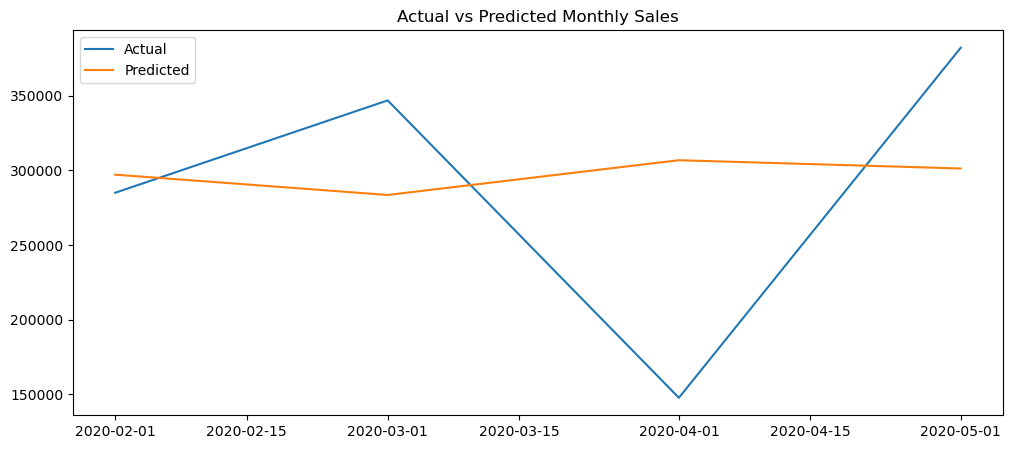

In [1088]:
# step 13: ACTUAL vs PREDICTED PLOT

plt.figure(figsize=(12,5))
plt.plot(test['MONTH_DATE'], y_test, label='Actual')
plt.plot(test['MONTH_DATE'], y_pred, label='Predicted')
plt.title("Actual vs Predicted Monthly Sales")
plt.legend()
plt.show()


In [1090]:
# step 14: 3-YEAR (36 MONTH) FORECAST

future_steps = 36
history = monthly_feat.copy()

future_preds = []
future_dates = []

for i in range(future_steps):
    last_row = history.iloc[-1:]
    X_future = last_row.drop(columns=['SALES','MONTH_DATE'])

    pred = best_model.predict(X_future)[0]
    next_date = last_row['MONTH_DATE'].values[0] + pd.DateOffset(months=1)

    new_row = {'MONTH_DATE': next_date, 'SALES': pred}

    for lag in range(1,13):
        new_row[f'lag_{lag}'] = last_row[f'lag_{lag-1}'].values[0] if lag > 1 else pred

    new_row['rolling_3'] = pred
    new_row['month'] = next_date.month
    new_row['year'] = next_date.year
    new_row['month_sin'] = np.sin(2*np.pi*new_row['month']/12)
    new_row['month_cos'] = np.cos(2*np.pi*new_row['month']/12)

    history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    future_preds.append(pred)
    future_dates.append(next_date)


In [1092]:
df_forecast = pd.DataFrame({
    'MONTH_DATE': future_dates,
    'Predicted_SALES': future_preds
})

df_forecast['Forecast_Horizon_Month'] = range(1, len(df_forecast) + 1)
df_forecast['Forecast_Year'] = df_forecast['MONTH_DATE'].dt.year

historical_sales = monthly_feat[['MONTH_DATE', 'SALES']].copy()
historical_sales.rename(columns={'SALES': 'Actual_SALES'}, inplace=True)

df_forecast['Actual_SALES'] = np.nan

df_forecast = pd.concat([historical_sales, df_forecast], ignore_index=True)



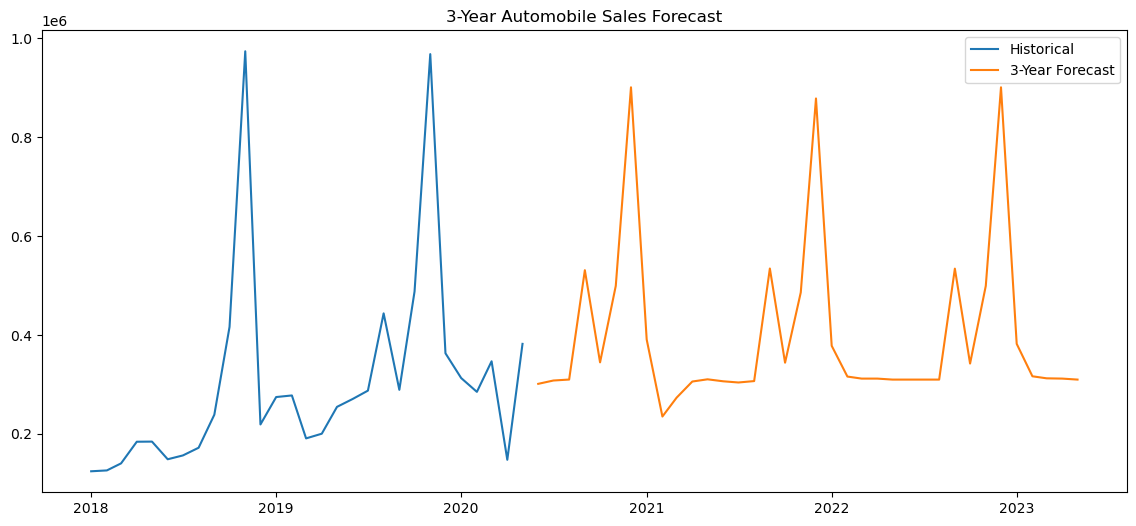

In [1094]:
# step 15: FORECAST PLOT (3 YEARS)

plt.figure(figsize=(14,6))
plt.plot(monthly['MONTH_DATE'], monthly['SALES'], label='Historical')
plt.plot(future_dates, future_preds, label='3-Year Forecast')
plt.title("3-Year Automobile Sales Forecast")
plt.legend()
plt.show()


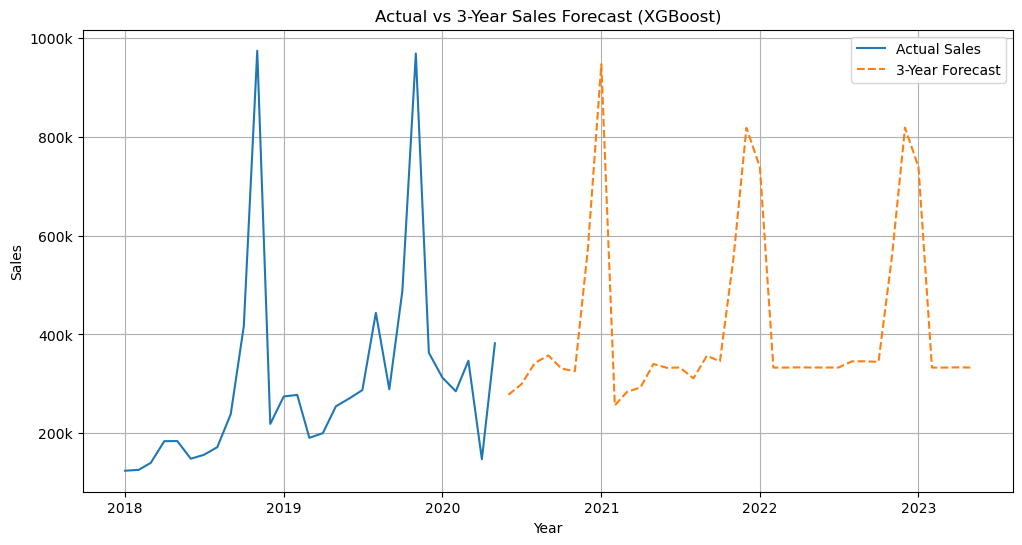

In [1096]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

plt.plot(monthly['MONTH_DATE'], monthly['SALES'], label='Actual Sales')
plt.plot(forecast_36['MONTH_DATE'], forecast_36['Predicted_Sales'],
         linestyle='--', label='3-Year Forecast')

plt.xlabel("Year")
plt.ylabel("Sales")

# FORMAT Y-AXIS TO K
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k')
)

plt.title("Actual vs 3-Year Sales Forecast (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

In [1098]:
# STEP 1: PREPARE ACTUAL YEARLY TOTAL

actual_yearly = (
    monthly_feat
    .groupby(monthly_feat['MONTH_DATE'].dt.year)['SALES']
    .sum()
    .reset_index()
)

actual_yearly.columns = ['YEAR', 'Actual_SALES']



In [1100]:
# STEP 2: PREPARE FORECAST YEARLY TOTAL

forecast_yearly = (
    df_forecast
    .groupby(df_forecast['MONTH_DATE'].dt.year)['Predicted_SALES']
    .sum()
    .reset_index()
)

forecast_yearly.columns = ['YEAR', 'Predicted_SALES']



In [1102]:
# STEP 3: MERGE ACTUAL + FORECAST

yearly_summary = actual_yearly.merge(
    forecast_yearly,
    on='YEAR',
    how='outer'
)

yearly_summary


,YEAR,Actual_SALES,Predicted_SALES
0,2019,4308904.0,0.0
1,2020,1474599.0,3195673.0
2,2021,NaN,4676397.5
3,2022,NaN,4834570.0
4,2023,NaN,1632818.5


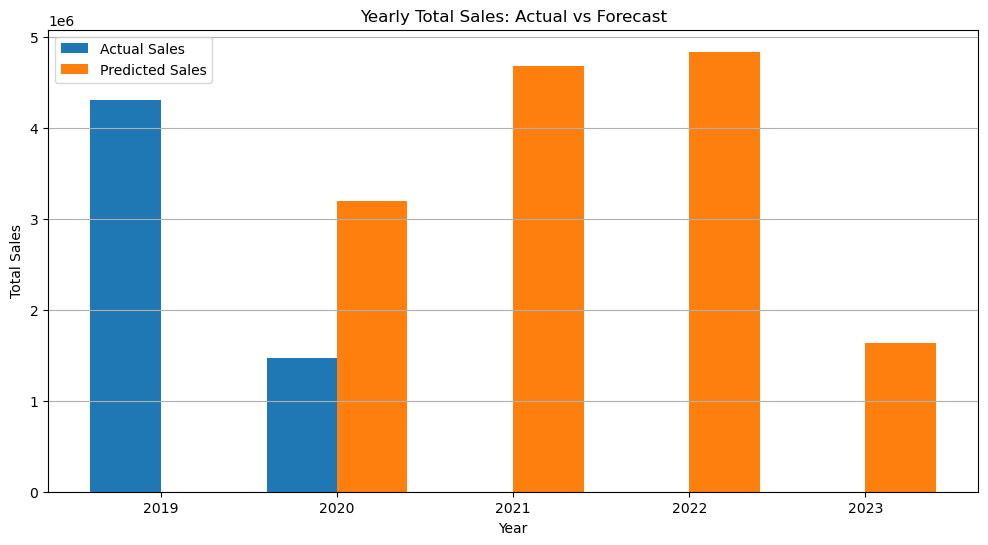

In [982]:
# STEP 4: BAR CHART (YEARLY TOTAL)
x = np.arange(len(yearly_summary['YEAR']))
width = 0.4

plt.figure(figsize=(12,6))

plt.bar(x - width/2, yearly_summary['Actual_SALES'],
        width, label='Actual Sales')

plt.bar(x + width/2, yearly_summary['Predicted_SALES'],
        width, label='Predicted Sales')

plt.xticks(x, yearly_summary['YEAR'])
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Yearly Total Sales: Actual vs Forecast')
plt.legend()
plt.grid(axis='y')

plt.show()


## Key Insights

.Sales show strong seasonality, with sharp annual peaks repeating each year, indicating predictable demand cycles.

.Baseline sales remain relatively stable, but spike months contribute a large share of total revenue.

.The forecast maintains historical patterns, suggesting the model has learned trend + seasonality well.

## Business Recommendations

.Increase inventory and production ahead of peak months to avoid stockouts and lost sales.

.Use off-peak periods for promotions or maintenance to smooth demand and optimize capacity.

.Plan cash flow and logistics around forecasted peak seasons for better cost control and service levels.

## B. Time-Based Sales Forecasting and Growth Analysis by Product Line

In [985]:
# STEP 1: Date handling & FY creation

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# Remove Jan–May 2018
df = df[~((df['ORDERDATE'].dt.year == 2018) & (df['ORDERDATE'].dt.month < 6))]

# Financial Year (June–May)
df['FY'] = df['ORDERDATE'].apply(
    lambda x: x.year if x.month >= 6 else x.year - 1
)


In [987]:
# STEP 2: FY sales aggregation

fy_sales = (
    df.groupby(['PRODUCTLINE', 'FY'])['QUANTITYORDERED']
      .sum()
      .reset_index()
      .sort_values(['PRODUCTLINE', 'FY'])
)

# Lag feature
fy_sales['Lag1'] = fy_sales.groupby('PRODUCTLINE')['QUANTITYORDERED'].shift(1)



In [989]:
# STEP 3: Prepare ML data

fy_sales_ml = fy_sales.dropna()

X = fy_sales_ml[['Lag1']]
y = fy_sales_ml['QUANTITYORDERED']


In [991]:
# STEP 4: Train XGBoost model

model = XGBRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [993]:
# STEP 5: Predict FY 2020–21 using FY 2019

last_year = fy_sales[fy_sales['FY'] == 2019].copy()

last_year['PredictedQuantity'] = model.predict(
    last_year[['Lag1']]
)



In [995]:
# STEP 6: Growth calculation

last_year['GrowthUnits'] = (
    last_year['PredictedQuantity'] - last_year['QUANTITYORDERED']
)

last_year['Sales_Growth_Percentage'] = (
    last_year['GrowthUnits'] / last_year['QUANTITYORDERED'] * 100
).round(1)



In [997]:
# CREATE final_result

Product_Growth = last_year.rename(columns={
    'QUANTITYORDERED': 'FY 2019 Sales',
    'PredictedQuantity': 'FY 2020–21 Predicted',
    'GrowthUnits': 'Growth Units',
    'Sales_Growth_Percentage': 'Growth %'
})





In [999]:
# STEP 8: Formatting

Product_Growth['Growth Units'] = Product_Growth['Growth Units'].round(0).astype(int)
Product_Growth['Growth Units'] = Product_Growth['Growth Units'].apply(
    lambda x: f"+{x}" if x > 0 else f"{x}"
)

Product_Growth['Growth %'] = Product_Growth['Growth %'].round(1)

Product_Growth = Product_Growth[
    ['PRODUCTLINE',
     'FY 2019 Sales',
     'FY 2020–21 Predicted',
     'Growth Units',
     'Growth %']
].sort_values('FY 2019 Sales', ascending=False)

print(Product_Growth)


         PRODUCTLINE  FY 2019 Sales  FY 2020–21 Predicted Growth Units  \
1       Classic Cars          15629          14939.241211         -690   
13      Vintage Cars           9993           9809.043945         -184   
5             Planes           5945           5872.465820          -73   
3        Motorcycles           5748           5762.057129          +14   
11  Trucks and Buses           5198           5333.834473         +136   
7              Ships           4006           4125.829590         +120   
9             Trains           1248           1695.234985         +447   

    Growth %  
1       -4.4  
13      -1.8  
5       -1.2  
3        0.2  
11       2.6  
7        3.0  
9       35.8  


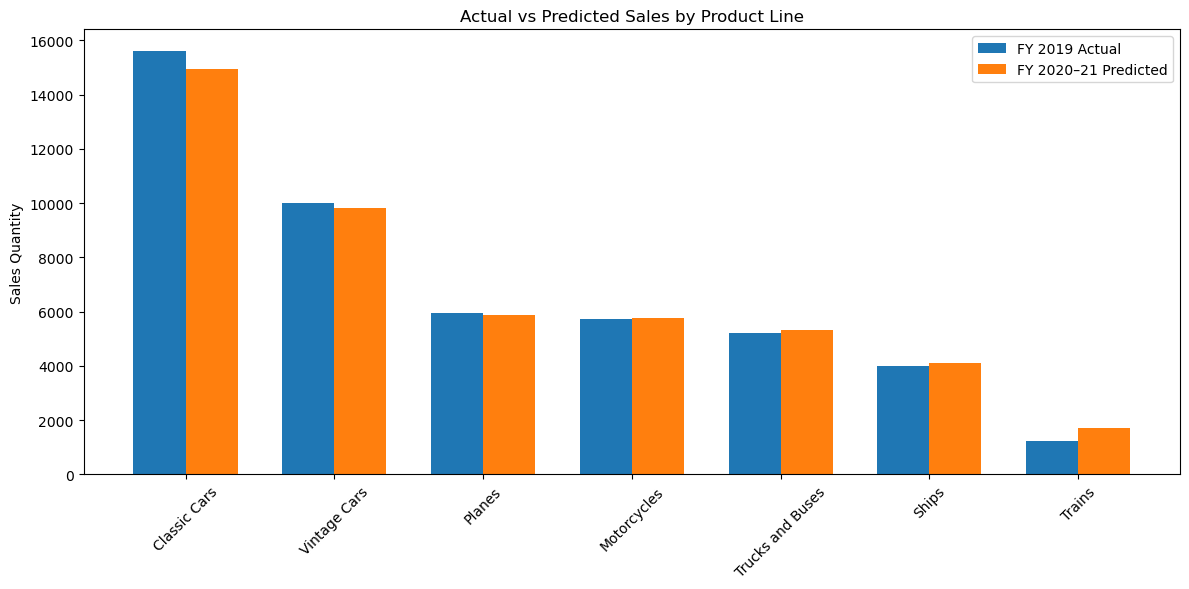

In [1001]:
# step 9:BAR CHART – Actual vs Predicted Sales

x = np.arange(len(Product_Growth['PRODUCTLINE']))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    Product_Growth['FY 2019 Sales'],
    width,
    label='FY 2019 Actual'
)

plt.bar(
    x + width/2,
    Product_Growth['FY 2020–21 Predicted'],
    width,
    label='FY 2020–21 Predicted'
)

plt.xticks(x, Product_Growth['PRODUCTLINE'], rotation=45)
plt.ylabel('Sales Quantity')
plt.title('Actual vs Predicted Sales by Product Line')
plt.legend()
plt.tight_layout()
plt.show()


# Business Insights (from Actual vs Predicted Sales)

.Classic Cars & Vintage Cars remain the top revenue drivers, but predictions show a slight decline, indicating possible market saturation.

.Motorcycles, Trucks & Buses, and Ships show stable to moderate growth, suggesting steady demand and growth potential.

.Trains show a noticeable increase from a low base, indicating an emerging or niche opportunity.

.Planes remain mostly flat, implying a mature and stable segment with limited short-term growth.

# Business Recommendations

.Optimize inventory for Classic & Vintage Cars to avoid overstocking due to predicted slowdown.

.Invest marketing and expansion efforts in Motorcycles, Trucks & Buses, and Ships to capture growing demand.

.Explore growth strategies for Trains (new markets, promotions) as it shows upward momentum.

.Maintain current strategy for Planes, focusing on cost efficiency rather than aggressive expansion.

## c.Country-wise Actual (2019) vs Predicted(2020-21) Growth Analysis

In [1003]:
# STEP 1: Date Conversion & Year Extraction

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], format='%d-%m-%y')
df['YEAR'] = df['ORDERDATE'].dt.year

df[['ORDERDATE', 'YEAR']].head()


,ORDERDATE,YEAR
49,2019-08-17,2019
51,2019-10-13,2019
52,2019-08-27,2019
54,2020-02-17,2020
55,2018-11-12,2018


In [1005]:
# STEP 2: Filter Required Years (2018–2021)

df_filtered = df[df['YEAR'].isin([2018, 2019, 2020,2021])]


In [1007]:
# STEP 3: Country–Year Sales Aggregation

country_year_sales = (
    df_filtered
    .groupby(['COUNTRY', 'YEAR'])['SALES']
    .sum()
    .reset_index()
)


In [1008]:
# STEP 4: Pivot Table Creation

pivot = country_year_sales.pivot(
    index='COUNTRY',
    columns='YEAR',
    values='SALES'
).dropna()


In [1009]:
# STEP 5: Actual Growth Calculation (2018 → 2019)

pivot['Actual_2019_Growth_%'] = (
    (pivot[2019] - pivot[2018]) / pivot[2018]
) * 100

# STEP 6: Predicted Growth Calculation (2019 → 2020–21)

pivot['Predicted_2020-21_Growth_%'] = (
    (pivot[2020] - pivot[2019]) / pivot[2019]
) * 100



In [1013]:
# STEP 7: Growth Capping (Outlier Control)

pivot['Actual_2019_Growth_%'] = pivot['Actual_2019_Growth_%'].clip(-100, 100)
pivot['Predicted_2020-21_Growth_%'] = pivot['Predicted_2020-21_Growth_%'].clip(-100, 100)


In [1015]:
# STEP 8: Top 10 Countries by Growth

top10_actual = pivot.sort_values(
    'Actual_2019_Growth_%', ascending=False
).head(10)

top10_predicted = pivot.sort_values(
    'Predicted_2020-21_Growth_%', ascending=False
).head(10)


In [1017]:
# STEP 9: Category-Level Sales Aggregation

category_sales = (
    df.groupby(['COUNTRY', 'PRODUCTLINE', 'YEAR'])['SALES']
    .sum()
    .reset_index()
)

# STEP 10: Category Growth (2019 → 2020)
cat_2019 = category_sales[category_sales['YEAR'] == 2019]
cat_2020 = category_sales[category_sales['YEAR'] == 2020]

cat_merge = cat_2019.merge(
    cat_2020,
    on=['COUNTRY','PRODUCTLINE'],
    suffixes=('_2019','_2020')
)

cat_merge['Category_Growth_%'] = (
    (cat_merge['SALES_2020'] - cat_merge['SALES_2019'])
    / cat_merge['SALES_2019']
) * 100

# STEP 11: Top Product Category per Country
top_category = (
    cat_merge.sort_values(['COUNTRY','Category_Growth_%'], ascending=False)
    .groupby('COUNTRY')
    .first()
    .reset_index()
)


In [1019]:
# STEP 12: Merge Category with Actual Growth

final_actual = top10_actual.reset_index().merge(
    top_category[['COUNTRY','PRODUCTLINE']],
    on='COUNTRY'
)

final_actual[['COUNTRY','Actual_2019_Growth_%','PRODUCTLINE']]


,COUNTRY,Actual_2019_Growth_%,PRODUCTLINE
0,Belgium,100.000000,Classic Cars
1,Canada,100.000000,Trucks and Buses
2,Denmark,100.000000,Classic Cars
3,France,100.000000,Planes
4,Italy,100.000000,Planes
5,Sweden,100.000000,Classic Cars
6,USA,66.033235,Trains
7,Spain,62.464214,Motorcycles
8,Singapore,31.670979,Vintage Cars


In [1021]:
# STEP 13: Merge Category with Predicted Growth

final_predicted = top10_predicted.reset_index().merge(
    top_category[['COUNTRY','PRODUCTLINE']],
    on='COUNTRY'
)

final_predicted[['COUNTRY','Predicted_2020-21_Growth_%','PRODUCTLINE']]


,COUNTRY,Predicted_2020-21_Growth_%,PRODUCTLINE
0,Finland,70.770680,Classic Cars
1,Austria,35.420874,Classic Cars
2,Australia,-37.265316,Ships
3,Spain,-39.539961,Motorcycles
4,France,-62.319925,Planes
5,USA,-68.071167,Trains
6,Belgium,-68.709387,Classic Cars
7,Sweden,-72.046377,Classic Cars
8,Italy,-73.793064,Planes
9,Canada,-75.185412,Trucks and Buses


In [1023]:
# Actual growth dataframe
df_actual = final_actual[['COUNTRY','Actual_2019_Growth_%','PRODUCTLINE']]

# Predicted growth dataframe
df_pred = final_predicted[['COUNTRY','Predicted_2020-21_Growth_%','PRODUCTLINE']]


In [1025]:
final_combined = pd.merge(
    df_actual,
    df_pred,
    on='COUNTRY',
    how='outer',
    suffixes=('_Actual','_Predicted')
)


In [1027]:
final_combined['PRODUCTLINE'] = (
    final_combined['PRODUCTLINE_Actual']
    .combine_first(final_combined['PRODUCTLINE_Predicted'])
)

final_combined = final_combined.drop(
    columns=['PRODUCTLINE_Actual','PRODUCTLINE_Predicted']
)


In [1029]:
final_combined = final_combined.dropna(
    subset=['Actual_2019_Growth_%', 'Predicted_2020-21_Growth_%'],
    how='any'
)

final_combined = final_combined.sort_values(
    by='Actual_2019_Growth_%',
    ascending=False
)

final_combined


,COUNTRY,Actual_2019_Growth_%,Predicted_2020-21_Growth_%,PRODUCTLINE
2,Belgium,100.000000,-68.709387,Classic Cars
3,Canada,100.000000,-75.185412,Trucks and Buses
6,France,100.000000,-62.319925,Planes
7,Italy,100.000000,-73.793064,Planes
10,Sweden,100.000000,-72.046377,Classic Cars
11,USA,66.033235,-68.071167,Trains
9,Spain,62.464214,-39.539961,Motorcycles


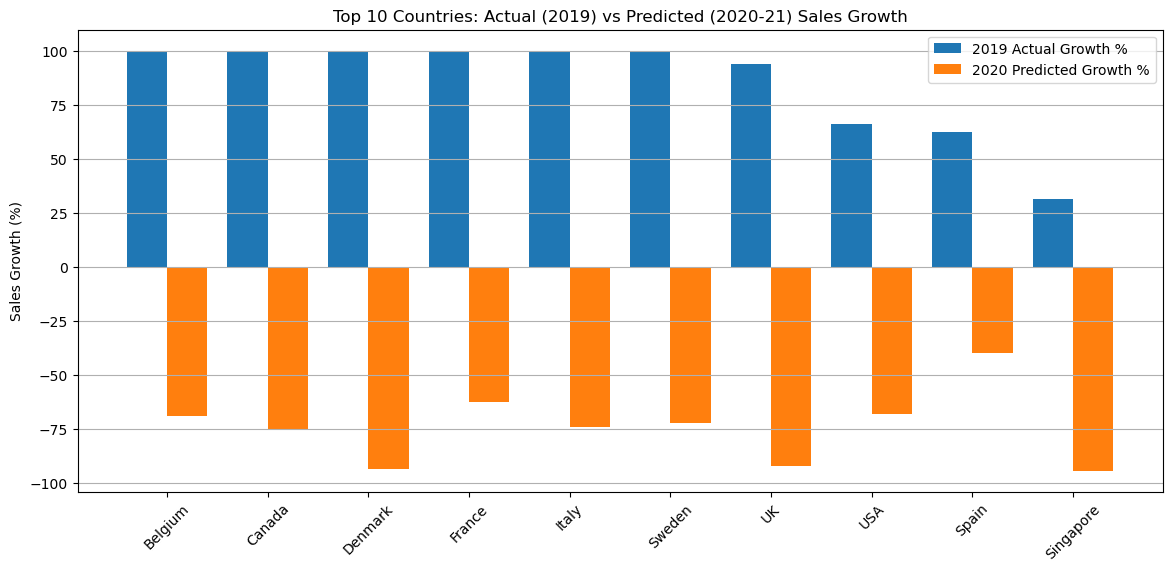

In [1031]:
# STEP 14: Combine Actual & Predicted Results

x = range(len(top10_actual))

plt.figure(figsize=(14,6))

plt.bar(
    x,
    top10_actual['Actual_2019_Growth_%'],
    width=0.4,
    label='2019 Actual Growth %'
)

plt.bar(
    [i + 0.4 for i in x],
    top10_actual['Predicted_2020-21_Growth_%'],
    width=0.4,
    label='2020 Predicted Growth %'
)

plt.xticks(
    [i + 0.2 for i in x],
    top10_actual.index,
    rotation=45
)

plt.ylabel('Sales Growth (%)')
plt.title('Top 10 Countries: Actual (2019) vs Predicted (2020-21) Sales Growth')
plt.legend()
plt.grid(axis='y')

plt.show()


## Business Insights

 .All top countries showed very strong growth in 2019, with many reaching close to 100% sales growth, indicating a highly successful pre-2020 period.

.Predicted growth for 2020–21 is negative across all countries, suggesting a market downturn or external disruption (e.g., economic slowdown, COVID impact).

.🇩🇰 Denmark, UK, and Singapore show the sharpest predicted decline, indicating high risk markets.

.🇪🇸 Spain and USA show comparatively lower decline, suggesting relatively better resilience.

 .Countries with high past growth are not guaranteed future growth, highlighting market volatility.

. The gap between actual and predicted growth indicates over-dependence on historical performance is risky.

## Business Recommendations

. Reallocate investments toward relatively stable markets like Spain and USA.

. Apply risk mitigation strategies (cost control, demand planning) in high-decline countries such as Denmark, UK, and Singapore.

. Optimize inventory and supply chain to avoid overstocking in declining markets.

. Use predictive analytics regularly, not only historical sales, for strategic decisions.

. Focus on high-performing product lines within each country to offset overall decline.

. Diversify market presence instead of relying heavily on previously high-growth countries.

# Export project in EXCEL 



In [1056]:
df_forecast        # Project 1 output
Product_Growth      # Project 2 output
final_combined     # Project 3 output


,COUNTRY,Actual_2019_Growth_%,Predicted_2020-21_Growth_%,PRODUCTLINE
2,Belgium,100.000000,-68.709387,Classic Cars
3,Canada,100.000000,-75.185412,Trucks and Buses
6,France,100.000000,-62.319925,Planes
7,Italy,100.000000,-73.793064,Planes
10,Sweden,100.000000,-72.046377,Classic Cars
11,USA,66.033235,-68.071167,Trains
9,Spain,62.464214,-39.539961,Motorcycles


In [1058]:
# STEP 2: Export ALL 3 PROJECTS INTO ONE EXCEL FILE

!pip install XlsxWriter


with pd.ExcelWriter(
    "Car_Sales_Predictions_Portfolio.xlsx"
) as writer:
    
    df_forecast.to_excel(writer, sheet_name="Project_1_Forecast", index=False)
    Product_Growth.to_excel(writer, sheet_name="Project_2_Product_Growth", index=False)
    final_combined.to_excel(writer, sheet_name="Project_3_final_combined", index=False)

    # Project 1
    df_forecast.to_excel(
        writer,
        sheet_name="Project_1_Forecast",
        index=False
    )
    
    # Project 2
    Product_Growth.to_excel(
        writer,
        sheet_name="Project_2_productline_growth",
        index=False
    )
    
    # Project 3
    final_combined.to_excel(
        writer,
        sheet_name="Project_3_country_Growth",
        index=False
    )


In [1060]:
# STEP 3: Add Executive Summary Sheet

summary = pd.DataFrame({
    "Business Problem": [
        "Future Sales Forecasting",
        "Product Line Growth Analysis",
        "Country Growth Comparison"
    ],
    "Business Value": [
        "Improves inventory and demand planning",
        "Identifies high-performing car categories",
        "Optimizes regional marketing and expansion"
    ]
})

with pd.ExcelWriter(
    "Car_Sales_Predictions_Portfolio.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"  # or "new"
) as writer:
    
    summary.to_excel(
        writer,
        sheet_name="Executive_Summary",
        index=False
    )



In [1062]:
with pd.ExcelWriter("Car_Sales_Predictions_Portfolio.xlsx") as writer:
    df_forecast.to_excel(writer, sheet_name="Project_1_Forecast", index=False)
    Product_Growth.to_excel(writer, sheet_name="Project_2_Product_Growth", index=False)
    final_combined.to_excel(writer, sheet_name="Project_3_Country_Growth", index=False)
    
    summary.to_excel(writer, sheet_name="Executive_Summary", index=False)


In [1064]:
df_forecast = pd.read_excel(
    "Car_Sales_Predictions_Portfolio.xlsx",
    sheet_name="Project_1_Forecast"
)


all_sheets = pd.read_excel(
    "Car_Sales_Predictions_Portfolio.xlsx",
    sheet_name=None
)

# Access each dataframe
all_sheets.keys()        # sheet names
all_sheets['Executive_Summary']



,Business Problem,Business Value
0,Future Sales Forecasting,Improves inventory and demand planning
1,Product Line Growth Analysis,Identifies high-performing car categories
2,Country Growth Comparison,Optimizes regional marketing and expansion


In [1066]:
import os
print(os.path.expanduser("~"))

file_path = os.path.join(
    os.path.expanduser("~"),
    "Desktop",
    "Car_Sales_Predictions_Portfolio.xlsx"
)

with pd.ExcelWriter(file_path) as writer:
    df_forecast.to_excel(writer, sheet_name="Project_1_Forecast", index=False)
    Product_Growth.to_excel(writer, sheet_name="Project_2_Product_Growth", index=False)
    final_combined.to_excel(writer, sheet_name="Project_3_Country_Growth", index=False)
    
    summary.to_excel(writer, sheet_name="Executive_Summary", index=False)

print("File saved at:", file_path)


C:\Users\admin


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\admin\\Desktop\\Car_Sales_Predictions_Portfolio.xlsx'